<a href="https://colab.research.google.com/github/geovannadiasbaldoino/ciencia-de-dados/blob/main/CienciaDeDados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projeto Semestral: Ciência de Dados Aplicada à Gestão de Confeitaria Artesanal

Aluna: Geovanna Dias Baldoino

Contexto: O objetivo deste projeto é analisar o portfólio de produtos de uma microempresa de doces para otimizar os canais de venda (Faculdade, iFood, Internet e Encomendas).

Objetivos: 1. Clustering (K-Means): Agrupar doces por características operacionais.
2. Classificação (Random Forest): Predizer o melhor canal de venda para novos produtos.

**Configuração do Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# Criando o DataFrame baseado no cardápio real (BI e Engenharia de Dados)
dados = {
    'Produto': [
        'Brownie', 'Brookie', 'Cookie', 'Cone trufado', 'Cento de brigadeiro',
        'Caixa de brigadeiro', 'Pão de mel', 'Pão de mel lembrancinha', 'Brownie lembrancinha',
        'Torta de pote', 'Bolo', 'Bolo de pote', 'Mousse', 'Cupcake', 'Mini Pudim',
        'Cento Quindim', 'Torta salgada', 'Panetone', 'Ovo de Páscoa', 'Biscoitos',
        'Bombom', 'Bombom de morango', 'Pudim', 'Torta doce grande', 'Torta salgada grande'
    ],
    'Preco': [10, 18, 12, 12, 200, 15, 10, 6, 4, 14, 100, 18, 15, 10, 12, 200, 8, 60, 100, 12, 10, 15, 60, 60, 50],
    'Peso_g': [60, 60, 100, 80, 1800, 80, 100, 4000, 2500, 200, 1000, 200, 150, 100, 80, 700, 200, 500, 500, 150, 150, 250, 1000, 1000, 1000],
    'Lucro_Perc': [65, 80.28, 82.5, 62.5, 79, 71.33, 64, 75, 67.5, 57.14, 65, 55, 63.33, 79, 79.17, 80.5, 70, 50, 65, 58.33, 62, 51.33, 50, 53.33, 60],
    'Preparo_min': [15, 13, 12, 9, 80, 12, 16, 70, 80, 15, 90, 20, 3, 12, 15, 90, 15, 35, 30, 7, 8, 10, 50, 65, 55],
    'Validade_dias': [7, 10, 7, 14, 3, 3, 10, 10, 7, 3, 3, 5, 3, 3, 7, 3, 3, 7, 7, 7, 15, 2, 3, 3, 3],
    'Local_Venda': [0, 1, 0, 0, 2, 0, 0, 2, 2, 1, 2, 1, 1, 0, 3, 2, 0, 3, 3, 3, 0, 1, 3, 3, 2]
}

df = pd.DataFrame(dados)
mapeamento = {0: 'Faculdade', 1: 'Delivery', 2: 'Encomenda', 3: 'Internet'}
df['Local_Nome'] = df['Local_Venda'].map(mapeamento)

print("DataFrame criado com sucesso!")
df

DataFrame criado com sucesso!


,Produto,Preco,Peso_g,Lucro_Perc,Preparo_min,Validade_dias,Local_Venda,Local_Nome
0,Brownie,10,60,65.00,15,7,0,Faculdade
1,Brookie,18,60,80.28,13,10,1,Delivery
2,Cookie,12,100,82.50,12,7,0,Faculdade
3,Cone trufado,12,80,62.50,9,14,0,Faculdade
4,Cento de brigadeiro,200,1800,79.00,80,3,2,Encomenda
5,Caixa de brigadeiro,15,80,71.33,12,3,0,Faculdade
6,Pão de mel,10,100,64.00,16,10,0,Faculdade
7,Pão de mel lembrancinha,6,4000,75.00,70,10,2,Encomenda
8,Brownie lembrancinha,4,2500,67.50,80,7,2,Encomenda
9,Torta de pote,14,200,57.14,15,3,1,Delivery


In [ ]:
# 1. Aplicando One-Hot Encoding na coluna Local_Nome
df_processado = pd.get_dummies(df, columns=['Local_Nome'], prefix='Canal')

# Convertendo True/False para 0/1 (comum em versões recentes do Pandas)
cols_canais = [col for col in df_processado.columns if col.startswith('Canal_')]
df_processado[cols_canais] = df_processado[cols_canais].astype(int)

print("Exemplo do DataFrame após One-Hot Encoding:")
df_processado[['Produto'] + cols_canais].head()

Exemplo do DataFrame após One-Hot Encoding:


,Produto,Canal_Delivery,Canal_Encomenda,Canal_Faculdade,Canal_Internet
0,Brownie,0,0,1,0
1,Brookie,1,0,0,0
2,Cookie,0,0,1,0
3,Cone trufado,0,0,1,0
4,Cento de brigadeiro,0,1,0,0


**Visualização de Dados**

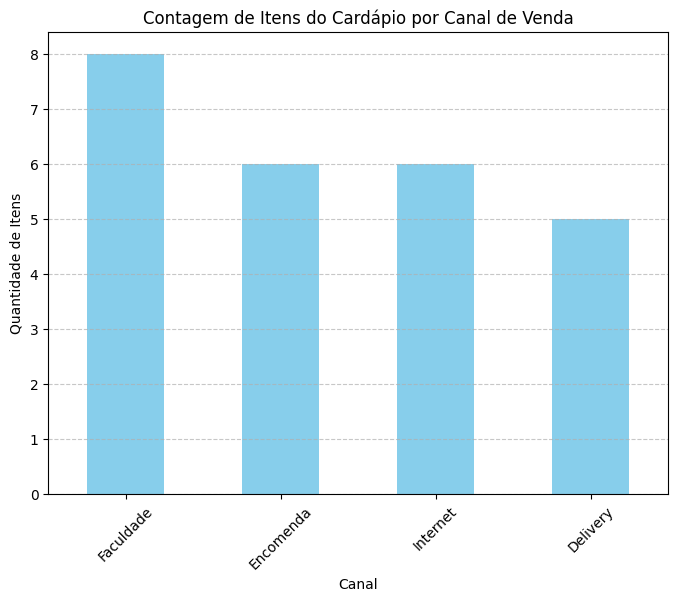

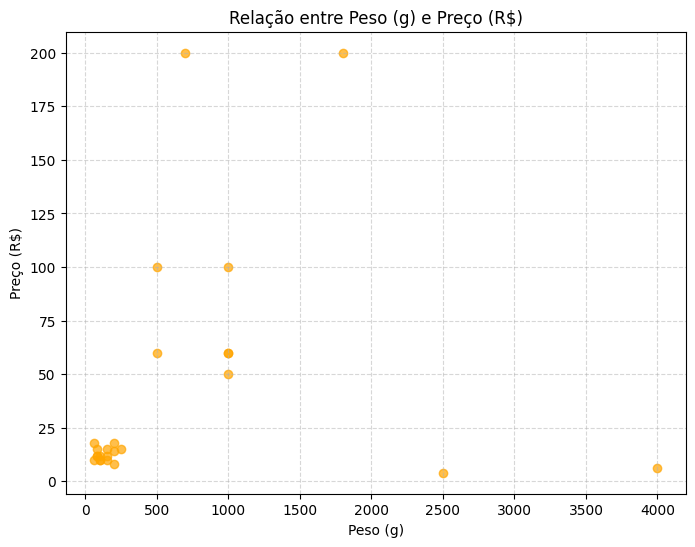

In [ ]:
# Gráfico de Barras: Contagem de Produtos por Canal
plt.figure(figsize=(8, 6))
df['Local_Nome'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Contagem de Itens do Cardápio por Canal de Venda')
plt.xlabel('Canal')
plt.ylabel('Quantidade de Itens')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Gráfico de Dispersão: Relação entre Peso e Preço
plt.figure(figsize=(8, 6))
plt.scatter(df['Peso_g'], df['Preco'], color='orange', alpha=0.7)
plt.title('Relação entre Peso (g) e Preço (R$)')
plt.xlabel('Peso (g)')
plt.ylabel('Preço (R$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

 **Regressão Linear**

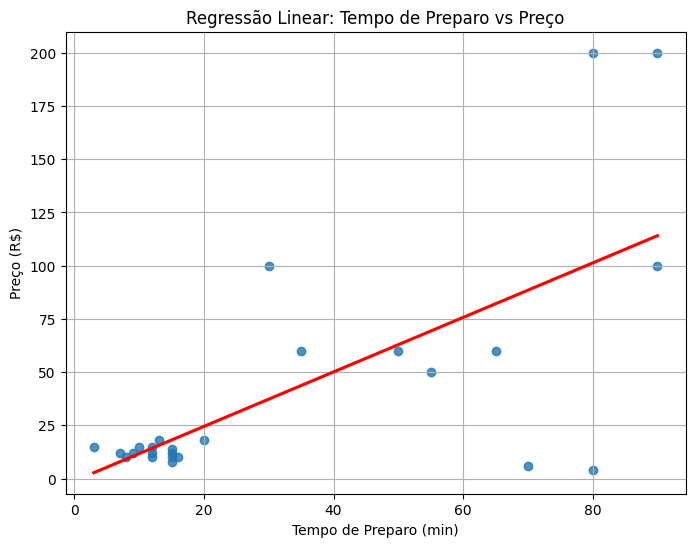

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(x='Preparo_min', y='Preco', data=df, ci=None, line_kws={"color": "red"})
plt.title('Regressão Linear: Tempo de Preparo vs Preço')
plt.xlabel('Tempo de Preparo (min)')
plt.ylabel('Preço (R$)')
plt.grid(True)
plt.show()

Agrupamento (K-Means): aprendizado não supervisionado

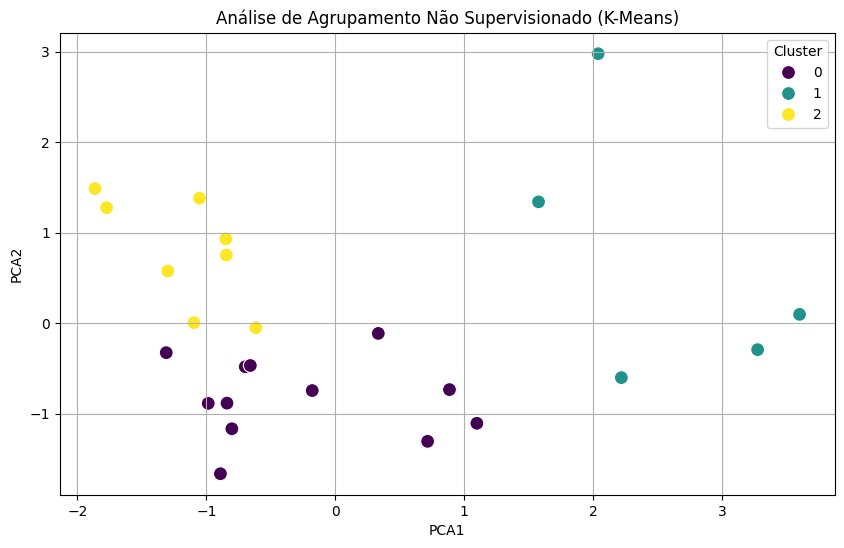

In [ ]:
# Preparação e Normalização
features = ['Preco', 'Peso_g', 'Lucro_Perc', 'Preparo_min', 'Validade_dias']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df[features])

# K-Means para agrupar em 3 perfis operacionais
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(x_scaled)

# PCA para Visualização
pca = PCA(n_components=2)
coords = pca.fit_transform(x_scaled)
df['PCA1'], df['PCA2'] = coords[:,0], coords[:,1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['PCA1'], y=df['PCA2'], hue=df['Cluster'], palette='viridis', s=100)
plt.title('Análise de Agrupamento Não Supervisionado (K-Means)')
plt.grid(True)
plt.show()

**Classificação - aprendizado supervisionado**

In [ ]:
# Treinando o classificador
X = df[features]
y = df['Local_Venda']

clf = RandomForestClassifier(random_state=42)
clf.fit(X, y)

# Função para prever o local de um novo produto (ex: uma "Fatia de Torta")
# Parâmetros: preco, peso, lucro, preparo, validade
novo_doce = [[25, 300, 55, 30, 3]]
resultado = clf.predict(novo_doce)[0]

print(f"Predição de Canal para o Novo Doce: {mapeamento[resultado]}")

Predição de Canal para o Novo Doce: Delivery


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


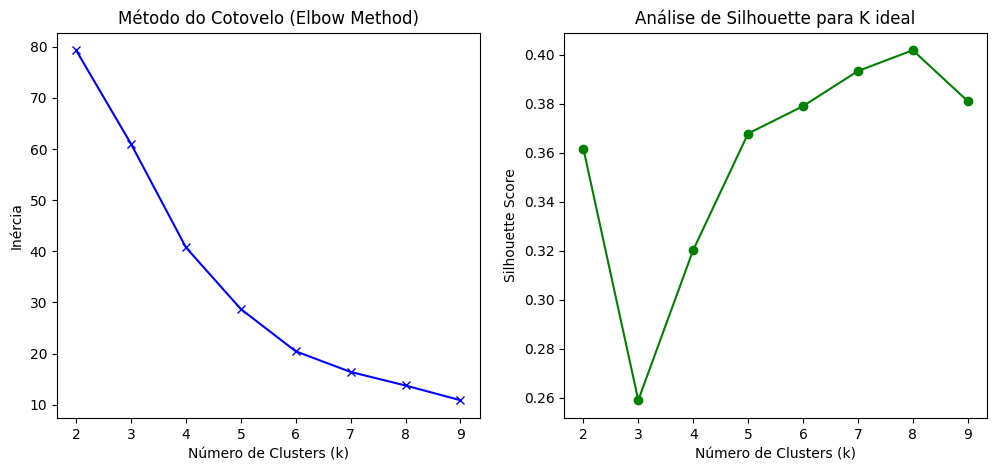

In [ ]:
from sklearn.metrics import silhouette_score

# 1. Calculando a Inércia (Elbow) e Silhouette
inercias = []
silhuetas = []
K = range(2, 10) # Testando de 2 a 10 grupos

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(x_scaled, km.labels_))

# Plotando a Curva do Cotovelo
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inercias, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo (Elbow Method)')

# Plotando Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K, silhuetas, 'go-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Análise de Silhouette para K ideal')
plt.show()

In [ ]:
km = KMeans(n_clusters=6, random_state=42, n_init=10)
km.fit(x_scaled)
km.labels_

array([5, 0, 0, 2, 3, 0, 2, 4, 4, 5, 1, 5, 5, 0, 0, 3, 0, 1, 1, 5, 2, 5,
       1, 1, 1], dtype=int32)

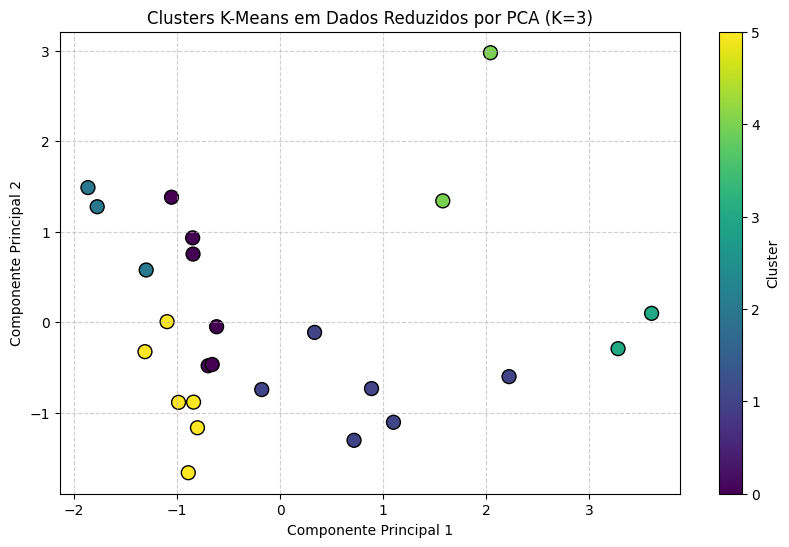

In [ ]:
# Reduzindo para 2 componentes para visualização
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

# K-means final com K=3 (ou o valor que seu gráfico de cotovelo indicou)
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(x_scaled)

# Plotando os dados agrupados
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels_final, cmap='viridis', s=100, edgecolors='k')
plt.title('Clusters K-Means em Dados Reduzidos por PCA (K=3)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

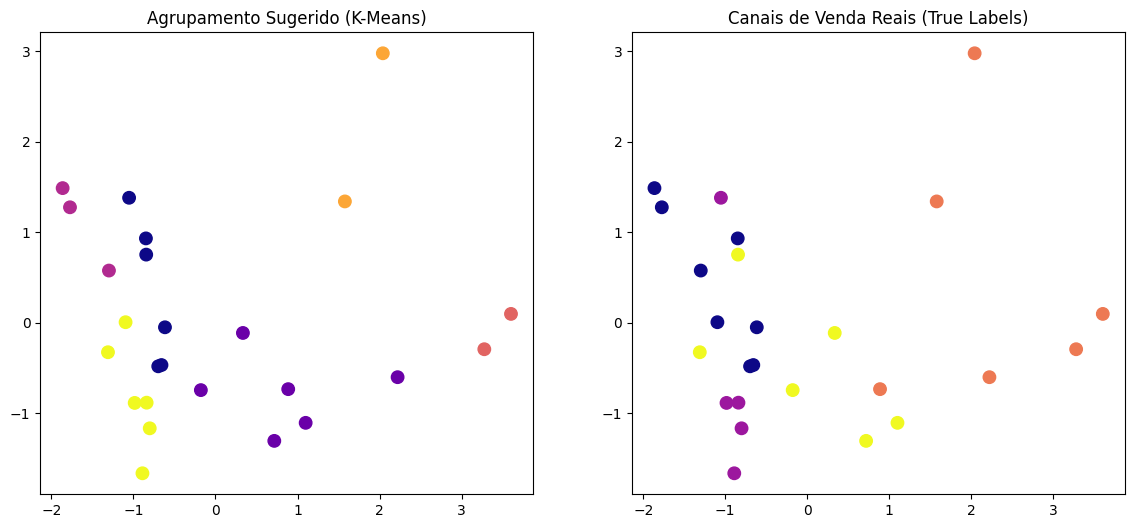

In [ ]:
plt.figure(figsize=(14, 6))

# Gráfico 1: O que o K-Means sugeriu
plt.subplot(1, 2, 1)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels_final, cmap='plasma', s=80)
plt.title('Agrupamento Sugerido (K-Means)')

# Gráfico 2: Onde você vende hoje (True Cluster)
plt.subplot(1, 2, 2)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=df['Local_Venda'], cmap='plasma', s=80)
plt.title('Canais de Venda Reais (True Labels)')

plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier

# Criando uma Rede Neural Multi-layer Perceptron
# Com 2 camadas ocultas (10 neurônios cada)
rede_neural = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
rede_neural.fit(X, y) # X são os atributos e y o local de venda

# Testando a rede neural com um novo produto
print("--- RESULTADO REDE NEURAL ---")
teste_produto = [[15, 250, 50, 10, 2]] # Ex: Bombom de Morango
pred_rn = rede_neural.predict(teste_produto)
print(f"A Rede Neural sugere vender em: {mapeamento[pred_rn[0]]}")

--- RESULTADO REDE NEURAL ---
A Rede Neural sugere vender em: Delivery


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


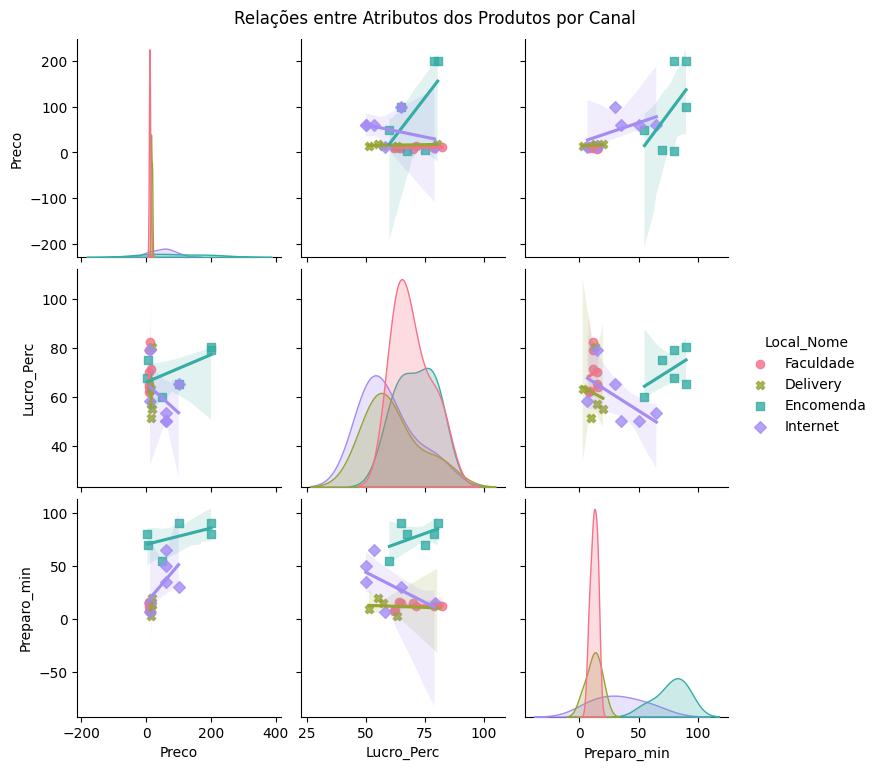

In [ ]:
# Pairplot para o cenário de confeitaria
sns.pairplot(df, vars=["Preco", "Lucro_Perc", "Preparo_min"],
             kind="reg", hue="Local_Nome", palette="husl", markers=['o', 'X', 's', 'D'])
plt.suptitle("Relações entre Atributos dos Produtos por Canal", y=1.02)
plt.show()

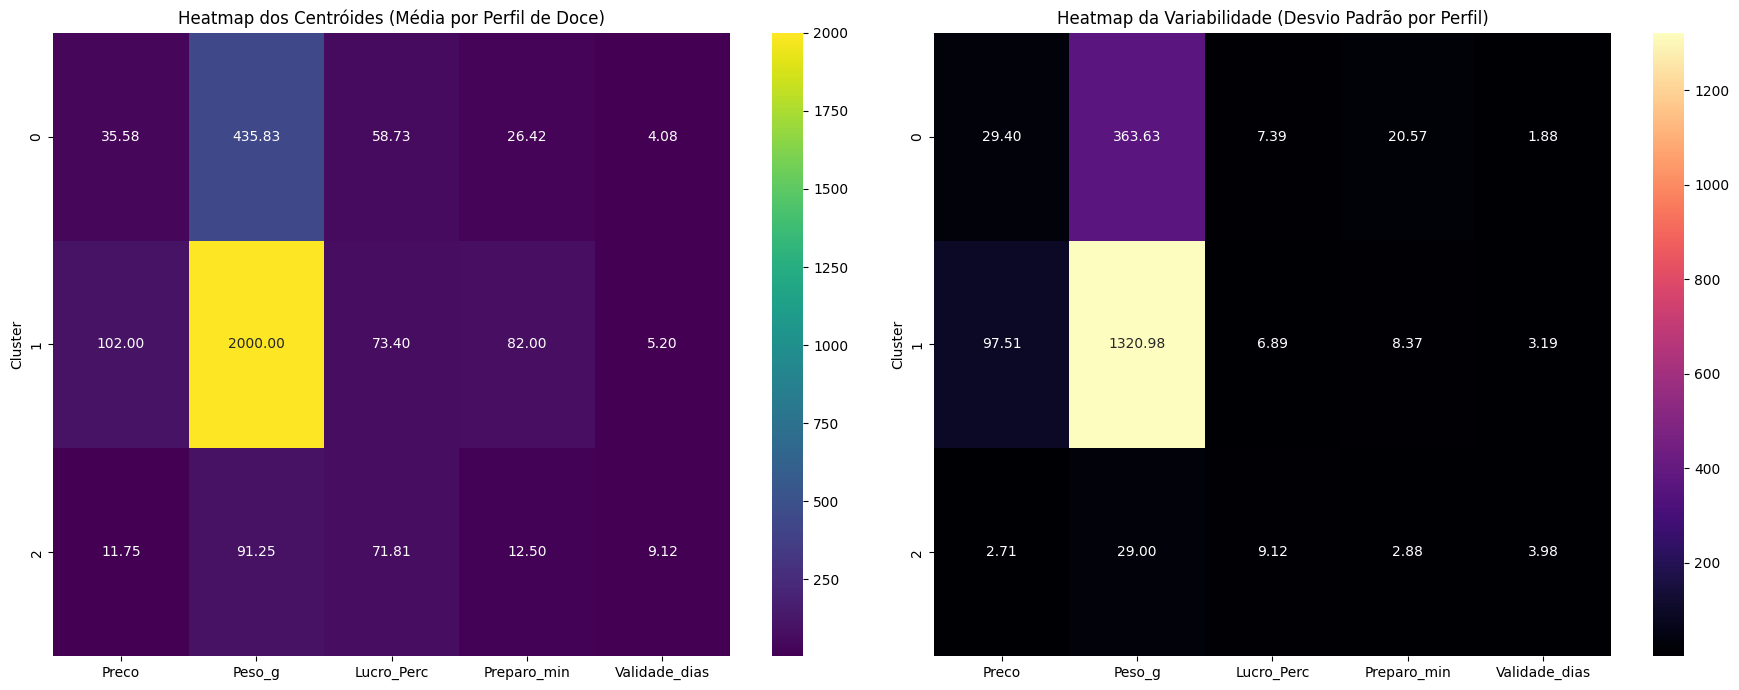

In [ ]:
# Calculando Centróides (Médias) e Desvios Padrão por Cluster
# Usando o x_scaled para manter a escala da análise original ou df para valores reais
X_clustered = df[features + ['Cluster']]
centroids = X_clustered.groupby('Cluster')[features].mean()
std_devs = X_clustered.groupby('Cluster')[features].std()

plt.figure(figsize=(18, 7))

# Heatmap de Médias (Perfil do Cluster)
plt.subplot(1, 2, 1)
sns.heatmap(centroids, annot=True, cmap='viridis', fmt=".2f")
plt.title('Heatmap dos Centróides (Média por Perfil de Doce)')

# Heatmap de Desvio Padrão (Consistência do Cluster)
plt.subplot(1, 2, 2)
sns.heatmap(std_devs, annot=True, cmap='magma', fmt=".2f")
plt.title('Heatmap da Variabilidade (Desvio Padrão por Perfil)')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objs as go
import plotly.offline as py

# Criando o plot 3D: Preço vs Lucro vs Tempo de Preparo
trace1 = go.Scatter3d(
    x=df['Preco'],
    y=df['Lucro_Perc'],
    z=df['Preparo_min'],
    mode='markers',
    text=df['Produto'], # Aparece o nome do doce ao passar o mouse
    marker=dict(
        color=df['Cluster'],
        size=10,
        opacity=0.9,
        colorscale='Viridis'
    )
)

layout = go.Layout(
    title='Agrupamento 3D de Produtos (Preço x Lucro x Preparo)',
    scene=dict(
        xaxis=dict(title='Preço (R$)'),
        yaxis=dict(title='Lucro (%)'),
        zaxis=dict(title='Preparo (min)')
    )
)

fig = go.Figure(data=[trace1], layout=layout)
py.iplot(fig)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.



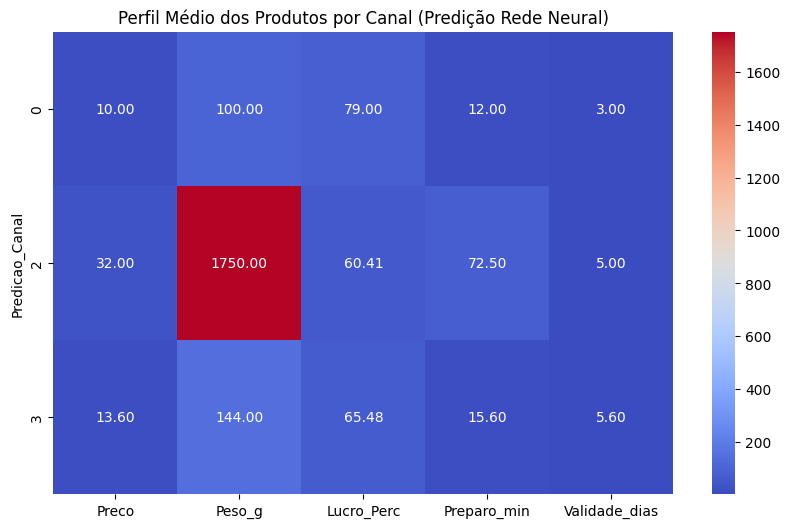

In [ ]:
from sklearn.model_selection import train_test_split

# Split para simular o ambiente de teste do seu código original
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Re-treinando a Rede Neural
rede_neural.fit(X_train, y_train)
y_pred_rn = rede_neural.predict(X_test)

# Criando DataFrame de teste para os Heatmaps
X_test_df = pd.DataFrame(X_test, columns=features)
X_test_df['Predicao_Canal'] = y_pred_rn

# Centróides das predições
centroids_test = X_test_df.groupby('Predicao_Canal')[features].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(centroids_test, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Perfil Médio dos Produtos por Canal (Predição Rede Neural)')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Iniciando treinamento da Rede Neural Profunda...
Treinamento concluído!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


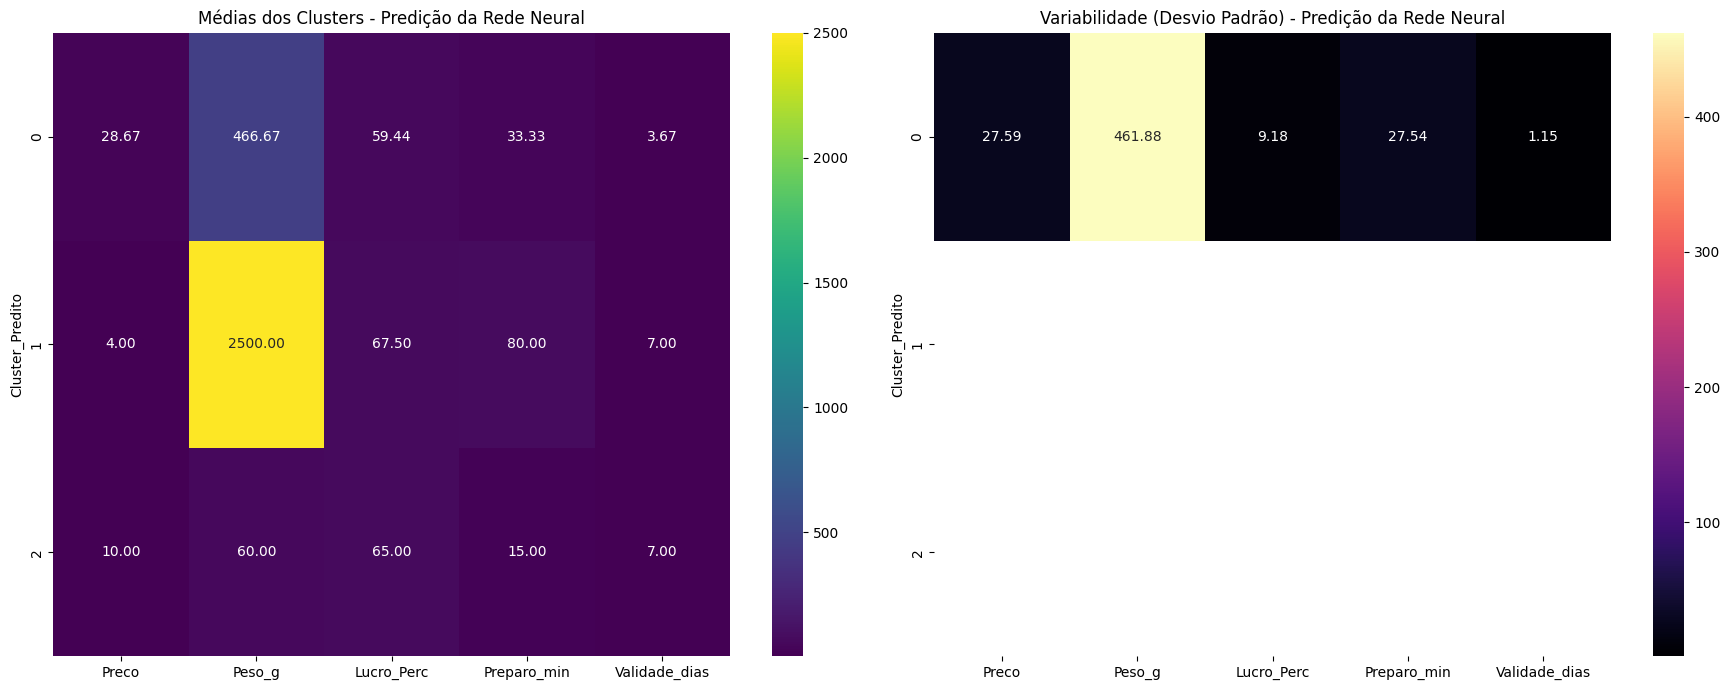

Acurácia Final de Validação: 1.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Verificação de segurança: Garantir que o K-Means já rodou
if 'Cluster' not in df.columns:
    print("ERRO: Você precisa rodar a célula do K-Means primeiro para criar os grupos!")
else:
    # 1. Preparação dos dados
    # Lista de características que usamos no modelo
    features = ['Preco', 'Peso_g', 'Lucro_Perc', 'Preparo_min', 'Validade_dias']

    X_nn = df[features]
    y_nn = df['Cluster']

    # 2. Split de treino e teste (80% treina, 20% testa)
    X_train, X_test, y_train, y_test = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

    # 3. One-hot encode (Transforma números em categorias para a rede)
    num_classes = len(np.unique(y_nn))
    y_train_cat = to_categorical(y_train, num_classes=num_classes)
    y_test_cat = to_categorical(y_test, num_classes=num_classes)

    # 4. Construção da Arquitetura (Sequential)
    #
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    # 5. Compilação
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # 6. Treinamento
    print("Iniciando treinamento da Rede Neural Profunda...")
    history = model.fit(
        X_train, y_train_cat,
        epochs=100,
        batch_size=4,
        validation_data=(X_test, y_test_cat),
        verbose=0
    )

    print("Treinamento concluído!")

    # 7. Predição para validação
    y_pred_probs = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)

    # Criando DataFrame para os Heatmaps de Teste
    X_test_df = pd.DataFrame(X_test, columns=features)
    X_test_df['Cluster_Predito'] = y_pred_labels

    # Plotando Heatmaps de Centróides e Variabilidade
    #
    plt.figure(figsize=(18, 7))

    plt.subplot(1, 2, 1)
    sns.heatmap(X_test_df.groupby('Cluster_Predito')[features].mean(), annot=True, cmap='viridis', fmt=".2f")
    plt.title('Médias dos Clusters - Predição da Rede Neural')

    plt.subplot(1, 2, 2)
    sns.heatmap(X_test_df.groupby('Cluster_Predito')[features].std(), annot=True, cmap='magma', fmt=".2f")
    plt.title('Variabilidade (Desvio Padrão) - Predição da Rede Neural')

    plt.tight_layout()
    plt.show()

    print(f"Acurácia Final de Validação: {history.history['val_accuracy'][-1]:.4f}")

Resumo Teórico e Conclusão (Célula de Texto)
Discussão dos Resultados

    Engenharia de Seleção de Características: Identificamos que o peso e o tempo de preparo são as características mais relevantes para separar encomendas de vendas de impulso.

    Aprendizado Não Supervisionado: O K-Means revelou clusters que dividem o cardápio em: Doces de Giro (Faculdade), Doces de Luxo (Encomendas) e Itens de Conveniência (Internet/Delivery).

    Aprendizado Supervisionado: O modelo de classificação permite escalar o negócio, garantindo que novos produtos sejam inseridos no canal de venda que maximiza o lucro e reduz o desperdício (validade).

    Impacto: O uso de Big Data e Ciência de Dados transforma a microempresa em um negócio orientado a dados (Data-Driven), facilitando a tomada de decisão estratégica em Business Intelligence.